
Processing: Respiratory infections and tuberculosis
Selected d: 1


C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided 

Best model: (2, 1, 0)

Ljung-Box Test:
     lb_stat  lb_pvalue
10  2.102635   0.995491


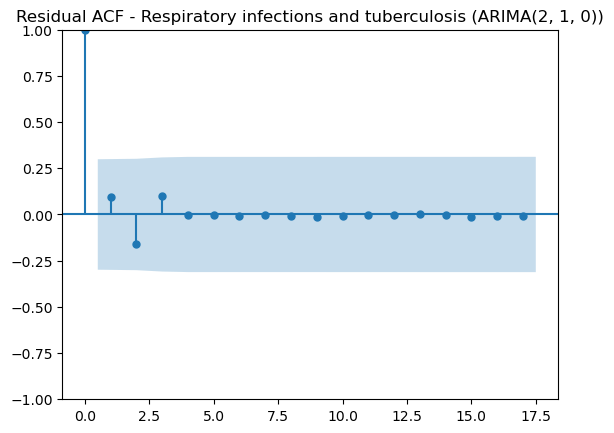

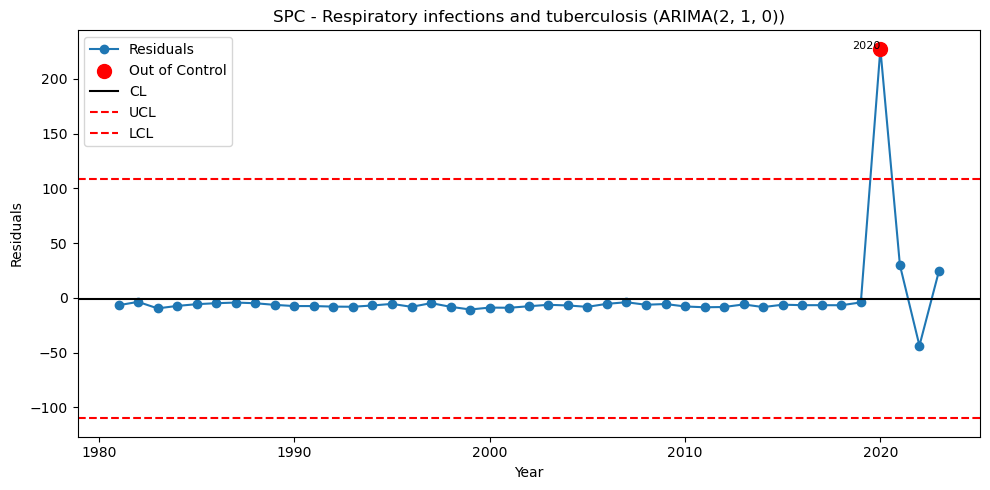


Processing: Cardiovascular diseases
Selected d: 1


C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided 

Best model: (2, 1, 0)

Ljung-Box Test:
     lb_stat  lb_pvalue
10  3.194992   0.976456


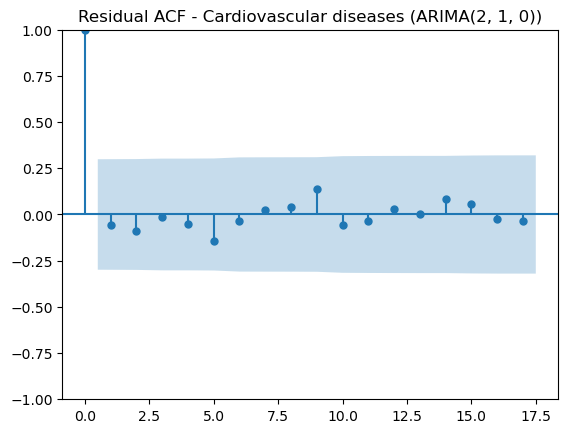

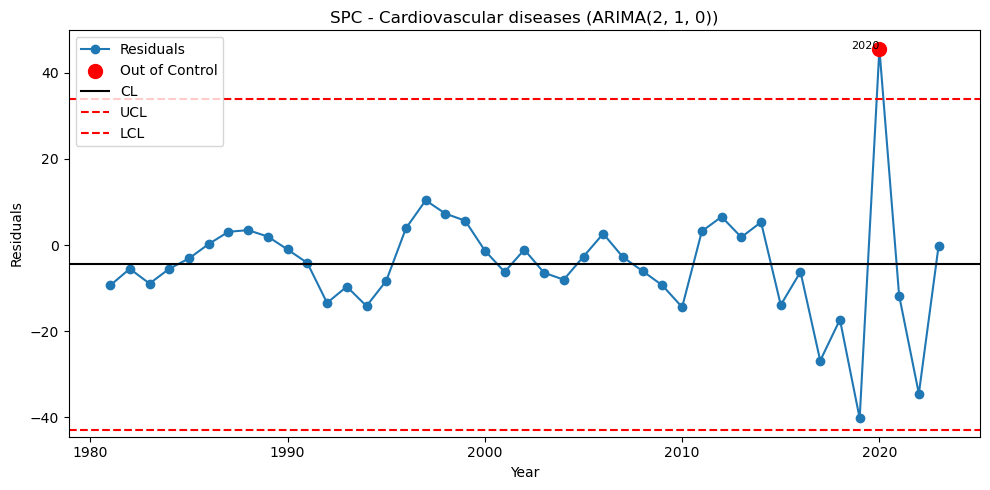


Processing: Chronic respiratory diseases
Selected d: 2


C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided 

Best model: (0, 2, 2)

Ljung-Box Test:
     lb_stat  lb_pvalue
10  7.539268   0.673741


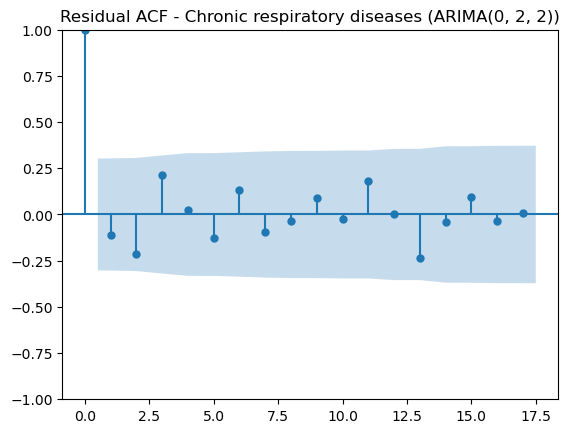

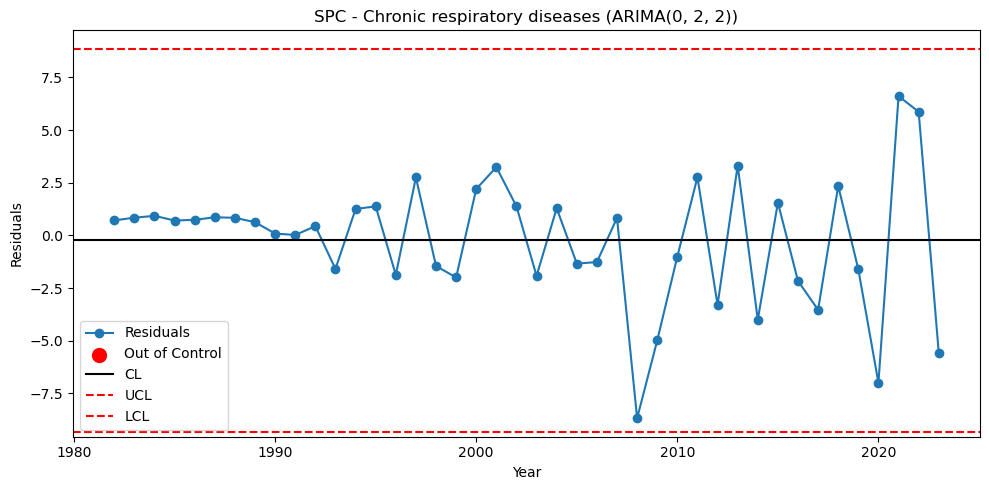

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Load data
df = pd.read_csv("C:/Users/kumar/Downloads/both_gender.csv")
df = df[df['location_name'] == 'Delhi']

diseases = [
    'Respiratory infections and tuberculosis',
    'Cardiovascular diseases',
    'Chronic respiratory diseases'
]

for disease in diseases:
    
    print("\n" + "="*60)
    print(f"Processing: {disease}")
    
    df_d = df[df['cause_name'] == disease].sort_values('year')
    ts = df_d['val']
    ts.index = df_d['year']
    
    
    # Find 
    temp = ts.copy()
    d = 0
    while adfuller(temp)[1] > 0.05 and d <= 2:
        temp = temp.diff().dropna()
        d += 1
    
    print("Selected d:", d)
    
    # Model Selection
    
    best_aic = np.inf
    best_model = None
    
    for p, q in itertools.product(range(3), range(3)):
        try:
            model = ARIMA(ts, order=(p, d, q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
                best_order = (p, d, q)
        except:
            continue
    
    print("Best model:", best_order)
    
    # -----------------------------
    # Residuals (correct slicing)
    # -----------------------------
    residuals = best_model.resid.iloc[d:]
    
    
    # CHECK 1: Ljung-Box Test (corrected)
    
    print("\nLjung-Box Test:")
    print(acorr_ljungbox(residuals, lags=[10], return_df=True))
    

    # CHECK 2: Residual ACF
    
    plot_acf(residuals)
    plt.title(f"Residual ACF - {disease} (ARIMA{best_order})")
    plt.show()
    

    # CHECK 3: SPC Chart (your format)
    
    mean = np.mean(residuals)
    std = np.std(residuals)
    
    ucl = mean + 3*std
    lcl = mean - 3*std
    
    out_of_control = (residuals > ucl) | (residuals < lcl)
    
    plt.figure(figsize=(10,5))
    
    plt.plot(residuals.index, residuals, marker='o', label='Residuals')
    
    plt.scatter(residuals.index[out_of_control],
                residuals[out_of_control],
                color='red',
                s=100,
                label='Out of Control',
                zorder=3)
    
    plt.axhline(mean, color='black', label='CL')
    plt.axhline(ucl, linestyle='--', color='red', label='UCL')
    plt.axhline(lcl, linestyle='--', color='red', label='LCL')
    
    for x, y in zip(residuals.index[out_of_control], residuals[out_of_control]):
        plt.text(x, y, str(x), fontsize=8, ha='right')
    
    plt.xlabel("Year")
    plt.ylabel("Residuals")
    plt.title(f"SPC - {disease} (ARIMA{best_order})")
    
    plt.legend()
    plt.tight_layout()
    plt.show()